In [2]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from data_store import get_df

In [3]:
def plot_learning_curves(csv_or_df, methods=None, title=None, smooth=0):
    df = pd.read_csv(csv_or_df) if isinstance(csv_or_df, (str, os.PathLike)) else csv_or_df.copy()
    if methods: df = df[df['method'].isin(methods)]
    df = df.sort_values(['method','round'])
    ycol = 'accuracy'
    if smooth and smooth > 1:
        df['acc_smooth'] = df.groupby('method')['accuracy'].transform(lambda s: s.rolling(smooth, 1).mean())
        ycol = 'acc_smooth'

    y0 = df.groupby('method').apply(lambda g: g.sort_values('round')[ycol].iloc[0]).min()
    y1 = min(1.0, df[ycol].max() + 0.01)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)

    for m, g in df.groupby('method'):
        axes[0].plot(g['round'], g[ycol], marker='o', linewidth=2, markersize=3, label=m)
    axes[0].set_xlabel('round'); axes[0].set_ylabel('accuracy')
    axes[0].set_ylim(max(0.0, y0 - 0.02), y1)
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].yaxis.set_major_locator(MaxNLocator(6))
    axes[0].grid(True, which='both', linestyle='--', alpha=0.35)

    if 'labels' in df.columns:
        for m, g in df.groupby('method'):
            axes[1].plot(g['labels'], g[ycol], marker='o', linewidth=2, markersize=3, label=m)
        axes[1].set_xlabel('labeled count')
        axes[1].set_ylim(max(0.0, y0 - 0.02), y1)
        axes[1].yaxis.set_major_locator(MaxNLocator(6))
        axes[1].grid(True, which='both', linestyle='--', alpha=0.35)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    axes[0].legend(loc='lower right', frameon=True)
    axes[1].legend(loc='lower right', frameon=True)
    if title: fig.suptitle(title)
    plt.show()
    return fig, axes

In [4]:
def plot_acc_pct(csv_or_df, methods=None, title=None,
                 y_min=0.0, y_max=1.0, use_top_k=True, band='std'):
    df = pd.read_csv(csv_or_df) if isinstance(csv_or_df, (str, os.PathLike)) else csv_or_df.copy()
    if methods:
        df = df[df['method'].isin(methods)].copy()

    tuple_col = 'acc_tuple_topk' if use_top_k else 'acc_tuple_top1'
    avg_col   = 'avg_acc_topk'   if use_top_k else 'avg_acc_top1'
    if tuple_col not in df.columns:
        if 'acc_tuple' in df.columns:
            tuple_col = 'acc_tuple'
        elif avg_col in df.columns:
            df[tuple_col] = df[avg_col].apply(lambda x: json.dumps([float(x)]))
        elif 'avg_acc' in df.columns:
            df[tuple_col] = df['avg_acc'].apply(lambda x: json.dumps([float(x)]))
        else:
            missing = [tuple_col, avg_col, 'acc_tuple', 'avg_acc']
            raise ValueError(f"Missing accuracy columns. Tried: {missing}")

    # Choose or compute % of pool (x-axis)
    if 'pct_before' in df.columns:
        df['pct'] = df['pct_before'].astype(float)
    elif 'pct' in df.columns:
        df['pct'] = df['pct'].astype(float)
    elif {'labels_before', 'pool_size'}.issubset(df.columns):
        df['pct'] = 100.0 * df['labels_before'].astype(float) / df['pool_size'].astype(float)
    elif {'labels', 'pool_size'}.issubset(df.columns):
        df['pct'] = 100.0 * df['labels'].astype(float) / df['pool_size'].astype(float)
    else:
        raise ValueError("Need either 'pct' or ('labels'|'labels_before' and 'pool_size').")

    def _parse_tuple(x):
        if isinstance(x, (list, tuple)): return tuple(float(v) for v in x)
        if pd.isna(x): return tuple()
        try: return tuple(float(v) for v in json.loads(x))
        except Exception:
            s = str(x).strip().strip('()[]')
            parts = [p for p in s.split(',') if p.strip()]
            return tuple(float(p) for p in parts)

    df['acc_tuple_use'] = df[tuple_col].apply(_parse_tuple)

    df_long = df.explode('acc_tuple_use', ignore_index=True).rename(columns={'acc_tuple_use': 'acc'})
    df_long['acc'] = pd.to_numeric(df_long['acc'], errors='coerce')
    df_long = df_long.dropna(subset=['acc'])
    if df_long.empty:
        raise ValueError("No accuracy data to plot.")

    summary = (
        df_long.groupby(['method', 'round'], as_index=False)
               .agg(mean_acc=('acc', 'mean'),
                    std_acc=('acc', 'std'),
                    n=('acc', 'count'),
                    pct=('pct', 'first'))
               .sort_values(['method', 'pct'])
    )
    summary['std_acc'] = summary['std_acc'].fillna(0.0)
    if band not in ('std', 'sem'):
        band = 'std'
    summary['band'] = summary['std_acc'] if band == 'std' else summary['std_acc'] / np.sqrt(summary['n'].clip(lower=1))

    methods_used = list(pd.unique(summary['method']))
    passive = [m for m in methods_used if m.startswith('passive_')]
    active  = [m for m in methods_used if m.startswith('active_')]
    other   = [m for m in methods_used if m not in passive + active]
    pal = {}
    if passive:
        c = sns.color_palette('Blues', max(3, len(passive)+1))[1:]
        pal.update({m: c[i] for i, m in enumerate(passive)})
    if active:
        c = sns.color_palette('Oranges', max(3, len(active)+1))[1:]
        pal.update({m: c[i] for i, m in enumerate(active)})
    if other:
        c = sns.color_palette('Greys', max(3, len(other)+1))[1:]
        pal.update({m: c[i] for i, m in enumerate(other)})

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(9, 5))

    sns.lineplot(
        data=summary, x='pct', y='mean_acc', hue='method',
        estimator=None, marker='o', linewidth=2, markersize=5,
        palette=pal, ax=ax
    )

    for m, g in summary.groupby('method'):
        x = g['pct'].to_numpy()
        y = g['mean_acc'].to_numpy()
        b = g['band'].to_numpy()
        if len(x) >= 2:
            lower = np.clip(y - b, 0.0, 1.0)
            upper = np.clip(y + b, 0.0, 1.0)
            ax.fill_between(x, lower, upper, color=pal[m], alpha=0.18, linewidth=0)

    ax.set_xlabel('Labeled budget (% of pool)')
    ax.set_ylabel('Accuracy')
    ax.set_xlim(float(summary['pct'].min()), float(summary['pct'].max()))
    ax.set_ylim(max(0.0, float(y_min)), min(1.0, float(y_max)))

    metric_label = f"Top-{int(df['top_k'].mode()[0])}" if use_top_k and 'top_k' in df.columns else "Top-1"
    ax.legend(title=f'Method ({metric_label})', frameon=True)
    if title:
        ax.set_title(title)
    plt.show()
    return fig, ax

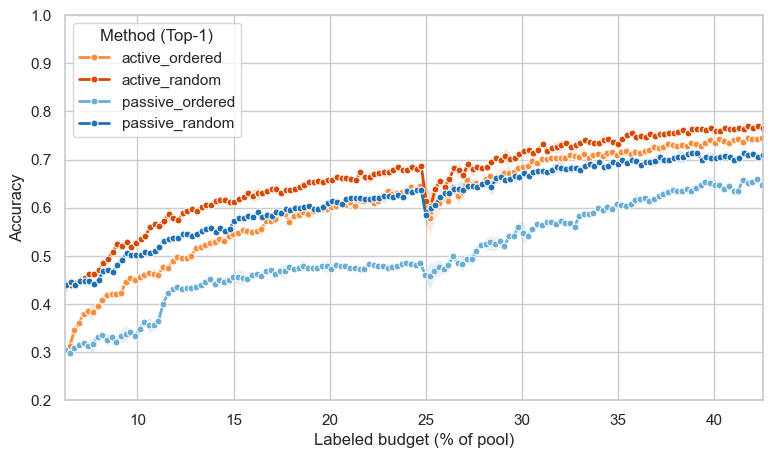

(<Figure size 900x500 with 1 Axes>,
 <Axes: xlabel='Labeled budget (% of pool)', ylabel='Accuracy'>)

In [ ]:
df = pd.read_csv('results/al_results_hash65536_lr0.0013005_bs512_ep16_k5_topk3_comm3_passcomm3_budget750_seed333_20250829_223114.csv')
# tilføj kolonne med classified i det loop
plot_acc_pct(df,y_min=0.2,y_max=1,use_top_k=False)

# y=0,x=0, 

In [6]:
plot_learning_curves(df)

KeyError: 'accuracy'

In [ ]:
def audit_learning_csv(csv_or_df, use_top_k=False, consensus_window=0.5):
    """
    Audit a learning-curve CSV to diagnose synchronized dips.
    Prints a human-readable report and returns a dict with details.

    Args:
        csv_or_df: path or DataFrame with columns at least:
            method, round, labels, pool_size, pct, avg_acc_top1, avg_acc_topk
        use_top_k: False -> analyze top-1, True -> analyze top-K
        consensus_window: +/- percentage points around the consensus dip to collect rows
    """
    df = pd.read_csv(csv_or_df) if isinstance(csv_or_df, (str, os.PathLike)) else csv_or_df.copy()

    metric_col = 'avg_acc_topk' if use_top_k else 'avg_acc_top1'
    if metric_col not in df.columns:
        raise ValueError(f"Missing column '{metric_col}' in CSV.")

    req = {'method', 'round', 'labels', 'pool_size', 'pct'}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing required columns: {sorted(missing)}")

    # ensure numeric types
    for c in ('round', 'labels', 'pool_size', 'pct', metric_col):
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['method', 'round', 'labels', 'pool_size', 'pct', metric_col])

    summaries = []
    dip_pcts = []

    print("\n=== AUDIT: Learning curves ===")
    families = []
    for mth, g in df.groupby('method', sort=False):
        g = g.sort_values('pct').reset_index(drop=True)

        # structural checks
        monot_labels = bool((np.diff(g['labels']) >= 0).all())
        monot_pct = bool((np.diff(g['pct']) >= 0).all())
        pools = g['pool_size'].unique()
        pool_ok = (len(pools) == 1)

        # step sizes (acquisitions) between rounds
        step = g['labels'].diff().fillna(0).astype(int).tolist()
        median_step = int(np.median([s for s in step if s > 0])) if any(s > 0 for s in step) else 0

        # deltas in chosen metric
        delta = g[metric_col].diff()
        # largest negative drop (min delta)
        idx_min = int(delta.idxmin()) if not delta.isna().all() else 0
        min_drop = float(delta.iloc[idx_min]) if idx_min > 0 else 0.0
        dip_pct = float(g.loc[idx_min, 'pct']) if idx_min > 0 else float('nan')
        dip_labels = int(g.loc[idx_min, 'labels']) if idx_min > 0 else int(g.loc[0, 'labels'])
        dip_round = int(g.loc[idx_min, 'round']) if idx_min > 0 else int(g.loc[0, 'round'])

        # acquisition size at the dip (labels_next - labels_curr)
        acq_size = int(g.loc[idx_min+1, 'labels'] - g.loc[idx_min, 'labels']) if idx_min+1 < len(g) and idx_min > 0 else 0

        summaries.append({
            'method': mth,
            'n_rows': len(g),
            'pool_ok': pool_ok,
            'pool_size_unique': pools.tolist(),
            'monot_labels': monot_labels,
            'monot_pct': monot_pct,
            'median_step': median_step,
            'min_drop': min_drop,
            'dip_pct': dip_pct,
            'dip_labels': dip_labels,
            'dip_round': dip_round,
            'acq_size_at_dip': acq_size,
        })
        if not np.isnan(dip_pct):
            dip_pcts.append(dip_pct)

    # consensus dip window (if multiple methods)
    consensus = float(np.median(dip_pcts)) if dip_pcts else float('nan')
    lo = consensus - consensus_window
    hi = consensus + consensus_window

    print("\n-- Per-method summary --")
    for s in summaries:
        print(
            f"{s['method']:>16} | rows={s['n_rows']:3d} | pool_ok={s['pool_ok']} "
            f"| step≈{s['median_step']:3d} | monot(labels/pct)={s['monot_labels']}/{s['monot_pct']} "
            f"| minΔ={s['min_drop']:+.4f} at {s['dip_pct']:.2f}% (round {s['dip_round']}, labels {s['dip_labels']}, acq {s['acq_size_at_dip']})"
        )

    print("\n-- Consensus dip window --")
    if dip_pcts:
        print(f"consensus≈{consensus:.2f}%  window=[{lo:.2f}%, {hi:.2f}%]")
    else:
        print("no dips detected (no negative deltas).")

    # collect rows around the dip window for inspection
    around = df[(df['pct'] >= lo) & (df['pct'] <= hi)].copy() if dip_pcts else pd.DataFrame()
    cols_show = ['method', 'round', 'pct', 'labels', 'pool_size', metric_col]
    around = around.sort_values(['method', 'pct'])[cols_show]

    print("\n-- Rows within consensus window --")
    if not around.empty:
        print(around.to_string(index=False, max_colwidth=20))
    else:
        print("(none)")

    # pack return
    out = {
        'summaries': summaries,
        'consensus_pct': consensus,
        'window': (lo, hi),
        'around': around,
        'metric': metric_col,
    }
    return out

audit_learning_csv(df)


=== AUDIT: Learning curves ===

-- Per-method summary --
  passive_random | rows=150 | pool_ok=True | step≈  5 | monot(labels/pct)=True/True | minΔ=-0.0532 at 25.01% (round 78, labels 514, acq 5)
 passive_ordered | rows=150 | pool_ok=True | step≈  5 | monot(labels/pct)=True/True | minΔ=-0.0246 at 24.96% (round 78, labels 513, acq 5)
   active_random | rows=150 | pool_ok=True | step≈  5 | monot(labels/pct)=True/True | minΔ=-0.0733 at 25.01% (round 78, labels 514, acq 5)
  active_ordered | rows=150 | pool_ok=True | step≈  5 | monot(labels/pct)=True/True | minΔ=-0.0383 at 24.96% (round 78, labels 513, acq 5)

-- Consensus dip window --
consensus≈24.99%  window=[24.49%, 25.49%]

-- Rows within consensus window --
         method  round       pct  labels  pool_size  avg_acc_top1
 active_ordered     77 24.720195     508       2055      0.644617
 active_ordered     78 24.963504     513       2055      0.606355
 active_ordered     79 25.206813     518       2055      0.577821
 active_ordered 

{'summaries': [{'method': 'passive_random',
   'n_rows': 150,
   'pool_ok': True,
   'pool_size_unique': [2055],
   'monot_labels': True,
   'monot_pct': True,
   'median_step': 5,
   'min_drop': -0.05317769130998695,
   'dip_pct': 25.012165450121653,
   'dip_labels': 514,
   'dip_round': 78,
   'acq_size_at_dip': 5},
  {'method': 'passive_ordered',
   'n_rows': 150,
   'pool_ok': True,
   'pool_size_unique': [2055],
   'monot_labels': True,
   'monot_pct': True,
   'median_step': 5,
   'min_drop': -0.02464332036316469,
   'dip_pct': 24.96350364963504,
   'dip_labels': 513,
   'dip_round': 78,
   'acq_size_at_dip': 5},
  {'method': 'active_random',
   'n_rows': 150,
   'pool_ok': True,
   'pool_size_unique': [2055],
   'monot_labels': True,
   'monot_pct': True,
   'median_step': 5,
   'min_drop': -0.07328145265888442,
   'dip_pct': 25.012165450121653,
   'dip_labels': 514,
   'dip_round': 78,
   'acq_size_at_dip': 5},
  {'method': 'active_ordered',
   'n_rows': 150,
   'pool_ok': True